# Run scMODAL for the integration of mouse brain scRNA-seq and scATAC-seq datasets

In this tutorial, we apply scMODAL to the integration of mouse brain scRNA-seq and scATAC-seq datasets. The raw datasets are available at http://mousebrain.org/adolescent/downloads.html and http://cf.10xgenomics.com/samples/cell-atac/1.1.0/atac_v1_adult_brain_fresh_5k/atac_v1_adult_brain_fresh_5k_filtered_peak_bc_matrix.h5. Preprocessed data can be found here: https://drive.google.com/drive/folders/1ARdFbgodjd5M1199dZcUF8AfG-CZ5ZJF?usp=sharing, where ATAC data were transfered to the gene activity matrix using Signac.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import os

import scmodal

import warnings
warnings.filterwarnings("ignore")

## Load data

In [2]:
adata_ATAC = ad.read_h5ad('./data/mouse_brain/adata_atac.h5ad')
adata_RNA = ad.read_h5ad('./data/mouse_brain/adata_rna.h5ad')

## Identify shared and unique features

In [3]:
sc.pp.highly_variable_genes(adata_RNA, flavor='seurat_v3', n_top_genes=1000)
sc.pp.normalize_total(adata_RNA)
sc.pp.log1p(adata_RNA)

sc.pp.highly_variable_genes(adata_ATAC, flavor='seurat_v3', n_top_genes=1000)
sc.pp.normalize_total(adata_ATAC)
sc.pp.log1p(adata_ATAC)

adata_RNA = adata_RNA[:, adata_RNA.var.highly_variable == True]
adata_ATAC = adata_ATAC[:, adata_ATAC.var.highly_variable == True]

sc.pp.scale(adata_RNA, max_value=10)
sc.pp.scale(adata_ATAC, max_value=10)

In [4]:
shared_features = sorted(adata_RNA.var.index & adata_ATAC.var.index)

adata_RNA = adata_RNA[:, shared_features+sorted(list(set(adata_RNA.var.index) - set(shared_features)))]
adata_ATAC = adata_ATAC[:, shared_features+sorted(list(set(adata_ATAC.var.index) - set(shared_features)))]

## Running scMODAL

In [5]:
model = scmodal.model.Model(training_steps=10000, n_KNN=5, model_path="./mousebrain_atac")
model.preprocess(adata_RNA, adata_ATAC, shared_gene_num=len(shared_features))

In [6]:
model.train()

Begining time:  Mon Apr 28 19:11:11 2025
step 0, loss_D=0.057128, loss_GAN=-0.047070, loss_AE=223.885498, loss_Geo=-3.227682, loss_LA=6076.462891, loss_MNN=47.184933
step 2000, loss_D=1.294264, loss_GAN=-1.284580, loss_AE=10.820892, loss_Geo=-19.497793, loss_LA=0.142464, loss_MNN=0.168658
step 4000, loss_D=1.324257, loss_GAN=-1.305007, loss_AE=10.348925, loss_Geo=-19.498384, loss_LA=0.163669, loss_MNN=0.180724
step 6000, loss_D=1.269320, loss_GAN=-1.262045, loss_AE=9.804791, loss_Geo=-19.498903, loss_LA=0.085581, loss_MNN=0.202978
step 8000, loss_D=1.311465, loss_GAN=-1.300777, loss_AE=9.727451, loss_Geo=-19.498585, loss_LA=0.081806, loss_MNN=0.194438
Ending time:  Mon Apr 28 19:24:27 2025
Training takes 795.80 seconds


In [7]:
model.eval()

Begining time:  Mon Apr 28 19:24:27 2025
Ending time:  Mon Apr 28 19:24:27 2025
Evaluating takes 0.08 seconds


In [9]:
adata_integrated = ad.AnnData(X=model.latent)
adata_integrated.obs = pd.concat([adata_RNA.obs, adata_ATAC.obs])
adata_integrated.obs['modality'] = ['RNA'] * adata_RNA.shape[0] + ['ATAC'] * adata_ATAC.shape[0]

scmodal.utils.compute_umap(adata_integrated)

UMAP(angular_rp_forest=True, local_connectivity=1, metric='correlation', min_dist=0.3, n_neighbors=30, random_state=1234, repulsion_strength=1, verbose=True)
Mon Apr 28 19:24:42 2025 Construct fuzzy simplicial set
Mon Apr 28 19:24:43 2025 Finding Nearest Neighbors
Mon Apr 28 19:24:43 2025 Building RP forest with 13 trees
Mon Apr 28 19:24:45 2025 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	Stopping threshold met -- exiting after 3 iterations
Mon Apr 28 19:25:03 2025 Finished Nearest Neighbor Search
Mon Apr 28 19:25:05 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Apr 28 19:25:30 2025 Finished embedding


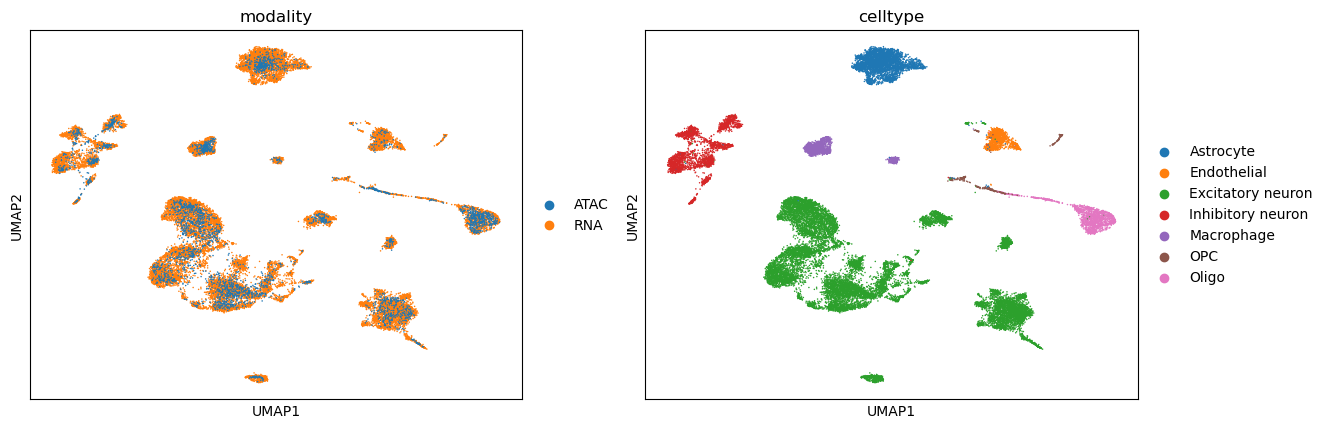

In [10]:
sc.pl.umap(adata_integrated, color=['modality', 'celltype'])